# ANN (Artificial Neural Network)
## TIPS 😀
---

### ACTIVATION FUNCTION FOR BEST RESULTS :

```
Use 'ReLU' for Hidden Layer
Use 'sigmoid' for Output Layer -> If it is Binary Classification (0 & 1)
Use 'softmax' for Output Layer -> If it is Multi Classification (0, 1, 2, 3....n)
Use 'linear' in Output Layer -> If it is Regression
```
---

### OPTIMIZER FOR BEST RESULTS :

`Use adam `
Adam (Adaptive Moment Estimation) is widely used as an optimizer because it combines the advantages of both Adagrad and RMSProp. It adapts the learning rate for each parameter by considering both the first and second moments of the gradients, leading to faster convergence and better performance, especially for complex problems.

---
### SCALER :

`'USE SCALER' For : `
- ANN
- Linear Regression
- Logistic Regression
- K Means
- SVM (Both for SVC and SVR)


> When using distance-based methods or Gradient Descent, a Scaler works very well because it ensures all features are on a similar scale, improving model performance.



`'Don't Use SCALER' for :`
- Decision Tree
- Random Forest
- XGBoost
- Adaboost
- Gradient Boosting


> We don’t need a scaler for boosting, bagging, or decision trees because these algorithms are not distance-based. Decision trees split data based on feature thresholds, and scaling doesn’t affect the splits. Boosting and bagging work on trees, so scaling doesn’t impact their performance.


---

### White Box Model and Black Box Model :


> A white-box model is a machine learning model where the decision-making process is transparent and easy to interpret

> A black-box model is complex and opaque, making its decisions difficult to understand

`White Box Model :`
- Linear Regression
- Logistic Regression
- Decision Regression
- KNN (for small datasets)
- Naive Bayes

`Black Box Model :`
- Ensemble Methods (Eg: Random Forest)
- Gradient Boosting (Eg: XGBoost, LightGBM, Catboost)
- SVM (with complex kernels)
- Deep Learning (Eg: ANN, CNN, RNN)

---




In [1]:
!pip install tensorflow

In [2]:
import tensorflow as tf
print(tf.__version__)

2.17.1


In [3]:
# Basic libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:
data = pd.read_csv('/content/11_Churn_Modelling_data.csv')

In [5]:
data.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
X = data.iloc[:, 3:13]  # Independent Feature
y = data.iloc[:, 13]  # Dependent Feature

In [7]:
X.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
0,619,France,Female,42,2,0.00,1,1,1,101348.88
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58
2,502,France,Female,42,8,159660.80,3,1,0,113931.57
3,699,France,Female,39,1,0.00,2,0,0,93826.63
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10


In [8]:
y.head()

,Exited
0,1
1,0
2,1
3,0
4,0


## **Feature Engineering**

In [9]:
geography = pd.get_dummies(X['Geography'], drop_first=True)
gender = pd.get_dummies(X['Gender'], drop_first=True)

In [10]:
# Drop Geography and Gender from dataset
X.drop(['Geography', 'Gender'], axis=1, inplace=True)

In [11]:
# Concatenate variable with dataframe
X = pd.concat([X, geography, gender], axis = 1)

In [12]:
# Splitting the dataset for Training and Testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [13]:
# Feature Scaling
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [14]:
X_train

array([[ 0.16958176, -0.46460796,  0.00666099, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-2.30455945,  0.30102557, -1.37744033, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-1.19119591, -0.94312892, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       ...,
       [ 0.9015152 , -0.36890377,  0.00666099, ..., -0.5698444 ,
        -0.57369368,  0.91601335],
       [-0.62420521, -0.08179119,  1.39076231, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       [-0.28401079,  0.87525072, -1.37744033, ...,  1.75486502,
        -0.57369368, -1.09168714]])

In [15]:
X_test

array([[-0.55204276, -0.36890377,  1.04473698, ...,  1.75486502,
        -0.57369368, -1.09168714],
       [-1.31490297,  0.10961719, -1.031415  , ..., -0.5698444 ,
        -0.57369368, -1.09168714],
       [ 0.57162971,  0.30102557,  1.04473698, ..., -0.5698444 ,
         1.74309049, -1.09168714],
       ...,
       [-0.74791227, -0.27319958, -1.37744033, ..., -0.5698444 ,
         1.74309049,  0.91601335],
       [-0.00566991, -0.46460796, -0.33936434, ...,  1.75486502,
        -0.57369368,  0.91601335],
       [-0.79945688, -0.84742473,  1.04473698, ...,  1.75486502,
        -0.57369368,  0.91601335]])

In [16]:
X_train.shape

(8000, 11)

In [17]:
X_test.shape

(2000, 11)

## **ANN Implementation**
- We gonna use **Tensorflow** which is developed by **Google**
- **Alternative**, you can use **PyTorch** which is developed by **Facebook**


> Note: TensorFlow has included Keras as part of its core from version 2.0 and onwards.



In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LeakyReLU, PReLU, ELU, ReLU
from tensorflow.keras.layers import Dropout

- Sequential ➡ Forward Propogation and Backword Propogation in ANN

- Dense ➡ Dense is used to create a fully connected layer in a neural network, specifying the number of units (neurons) and the activation function

- ReLU ➡ ReLU (Rectified Linear Unit) is an activation function
`Example : tf.keras.layers.Dense(64, activation='relu')`

- Dropout ➡ Dropout is a regularization technique in deep learning where randomly selected neurons are ignored during training to prevent overfitting.

In [19]:
# Initializing ANN
classifier = Sequential()

In [20]:
# Adding the Input Layer and The First hidden Layer of 11 Neurons
classifier.add(Dense(units=11, activation='relu'))

In [21]:
# Adding second hidden Layer
classifier.add(Dense(units=6, activation='relu'))

In [22]:
# Adding the output layer
classifier.add(Dense(1, activation='sigmoid'))

In [23]:
classifier.compile(optimizer = 'adam', loss='binary_crossentropy', metrics=['accuracy'])

Default Learning Rate of Adam : 0.1
If you want to give custom learning rate


```
import tensorflow
adam_opt = tensorflow.keras.optimizers.Adam(learning_rate = 0.01)
classifier.compile(optimizer = adam_opt, loss='binary_crossentropy', metrics=['accuracy'])
```



> Early stopping is a technique in deep learning that halts training when the model's performance on the validation set stops improving, preventing overfitting




In [24]:
import tensorflow as tf
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    min_delta=0,
    patience=0,
    verbose=0,
    mode="auto",
    baseline=None,
    restore_best_weights=False,
    start_from_epoch=0,
)



> So, We have used 1000 epochs, We will not wait to complete the epochs till 1000. It will stop on when the performance stop imporving so that will be our best epochs




In [25]:
model_history = classifier.fit(X_train, y_train, validation_split=0.33, batch_size=10, epochs=1000, callbacks = early_stopping)

Epoch 1/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - accuracy: 0.6471 - loss: 0.6372 - val_accuracy: 0.8042 - val_loss: 0.4643
Epoch 2/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7991 - loss: 0.4561 - val_accuracy: 0.8152 - val_loss: 0.4282
Epoch 3/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8185 - loss: 0.4137 - val_accuracy: 0.8236 - val_loss: 0.4105
Epoch 4/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8317 - loss: 0.3925 - val_accuracy: 0.8342 - val_loss: 0.3937
Epoch 5/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8537 - loss: 0.3590 - val_accuracy: 0.8410 - val_loss: 0.3810
Epoch 6/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8502 - loss: 0.3618 - val_accuracy: 0.8436 - val_loss: 0.3764
Epoch 7/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8497 - loss: 0.3546 - val_accuracy: 0.8459 - val_loss: 0.3722
Epoch 8/1000
536/536 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8563 - loss: 0.3446 

In [26]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

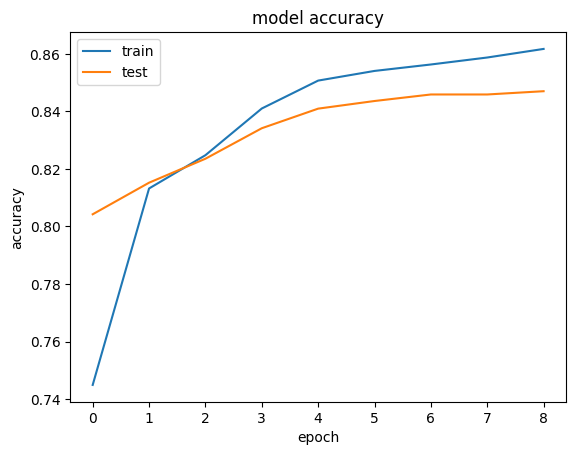

In [27]:
# summarize history for accuracy
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

## **Predictions**

In [28]:
y_pred = classifier.predict(X_test)
y_pred = (y_pred > 0.5)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [30]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1503,   92],
       [ 189,  216]])

In [31]:
score = accuracy_score(y_test, y_pred)
score

0.8595

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.91      1595
           1       0.70      0.53      0.61       405

    accuracy                           0.86      2000
   macro avg       0.79      0.74      0.76      2000
weighted avg       0.85      0.86      0.85      2000

